# Feature Map and Grad-CAM Analysis

In [31]:
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from model.image_processing import preprocess_fundus_adaptive
from model.feature_map import FeatureMapExtractor
from model.gradcam import GradCAM

IMG_PATH = 'diabetic-retinopathy.jpg'
MODEL_PATH = r'Resnet50_best' # PLEASE UPDATE: Point this to your model file

## 1. Load Model and Image

In [32]:
model = tf.keras.models.load_model(MODEL_PATH)
image_bgr = cv2.imread(IMG_PATH)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
# NOTE: Ensure target_size matches your model's expected input size\n
processed_image = preprocess_fundus_adaptive(image_rgb, target_size=256)
input_tensor = np.expand_dims(processed_image, axis=0)

## 2. Hierarchical Feature Map Visualization

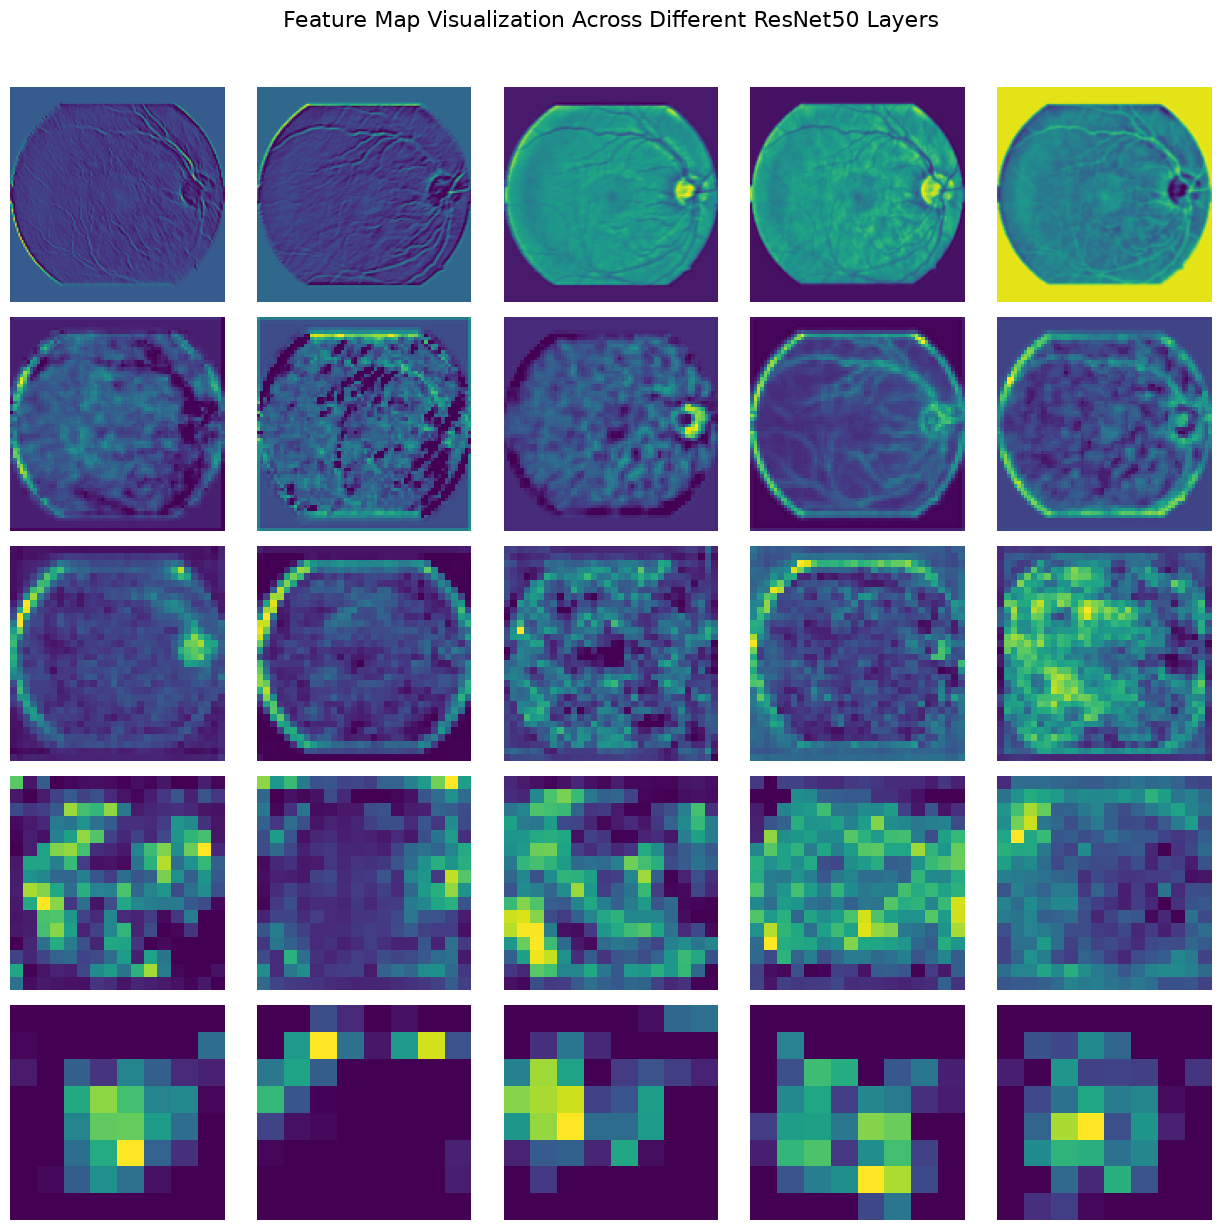

In [33]:
feature_extractor = FeatureMapExtractor(model)

layer_names = [
    'conv1_relu', 
    'conv2_block3_out',
    'conv3_block4_out',
    'conv4_block6_out',
    'conv5_block3_out'
]

n_rows = 5
n_cols = 5
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2.5, n_rows * 2.5))
fig.suptitle('Feature Map Visualization Across Different ResNet50 Layers', fontsize=16)

for i, layer_name in enumerate(layer_names):
    feature_map = feature_extractor.extract_layer(input_tensor, layer_name)
    
    # Select 5 most activated feature maps
    mean_activations = np.mean(feature_map, axis=(0, 1))
    top_5_indices = np.argsort(mean_activations)[-5:]
    
    for j, channel_index in enumerate(top_5_indices):
        ax = axes[i, j]
        ax.imshow(feature_map[:, :, channel_index], cmap='viridis')
        ax.axis('off')
        if j == 0:
            ax.set_ylabel(layer_name, rotation=90, size='large')
            
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('feature_maps_grid_5x5.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Grad-CAM Visualization

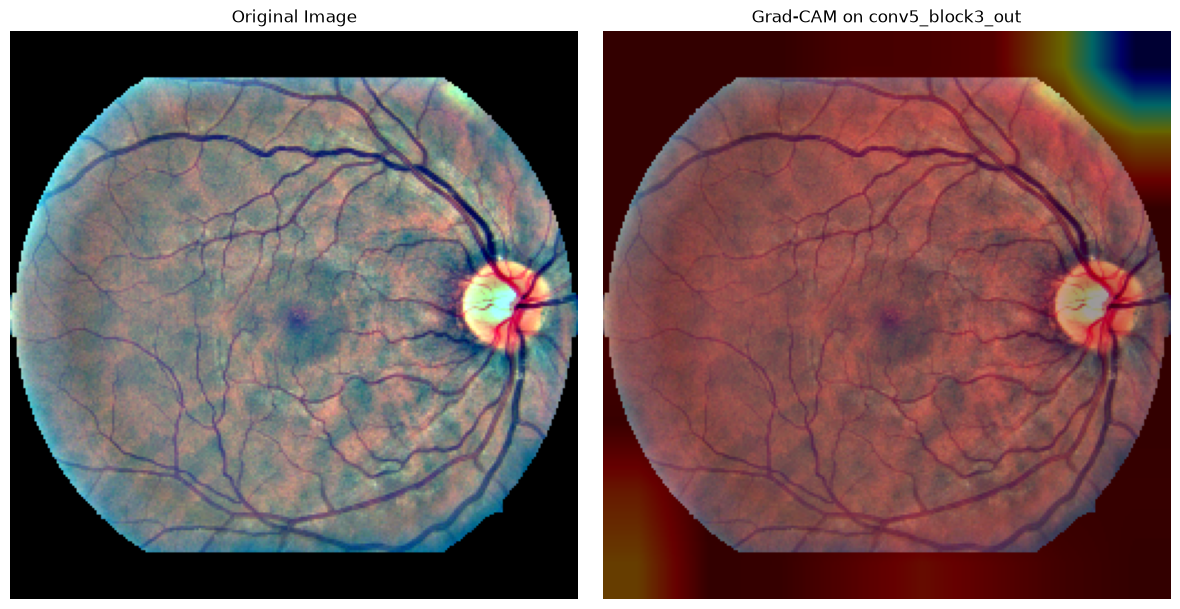

In [34]:
gradcam = GradCAM(model)
gradcam_layer = 'conv5_block3_out'

heatmap = gradcam.generate(input_tensor, gradcam_layer)
heatmap = cv2.resize(heatmap, (processed_image.shape[1], processed_image.shape[0]))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed_img = cv2.addWeighted(processed_image, 0.6, heatmap, 0.4, 0)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(processed_image)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(superimposed_img)
plt.title(f'Grad-CAM on {gradcam_layer}')
plt.axis('off')

plt.tight_layout()
plt.show()